# Gradient Boosting (XGBoost / LightGBM) segmentation of spectrogram-derived features

This notebook trains a **Gradient boosted tree-based classifier** (XGBoost or LightGBM) to predict a **multiclass mask** over time. We treat segmentation as **time-bin classification** (one row per time index), and compute **Dice per recording/window**. __DICE__ gies an evaluation of the model efficnecy to segment different patterns in the EEG.

Within the notebook there is possibility to:

- merge some classes between them (MERGE_ENABLE)
- add lags for the model
- Scale features (ADD_SCALER, in case of scaling, the scaler must be saved)

In [1]:
model_name = 'model_10_classes_lags'

# load Dataset

In [6]:
process = True # say false if no new mask have been done in datset to load directly the processed dataset (eeg, spectro, mask)

classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']

In [7]:
import os
import numpy as np
import json
from pathlib import Path

def load_mask_with_spectrograms(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

if process == True:

    # List all elements (files and folders)
    elements = os.listdir('data_mask_spectro/')

    X_eeg =  []
    X_spec = []
    Y = []

    for elem in elements:
        if '.json' in elem:
            # load masks and spectrogram
            data = load_mask_with_spectrograms('data_mask_spectro/' + elem)
            # load recording (use try except since can be from 2 different folders)
            try:
                y = np.load('anesthesia_database/' + data['recording'])
            except:
                y = np.load('anesthesia_database_Trousseau/' + data['recording'])
            # load window key names
            list_windows_keys = list(data['windows'].keys())
            # iterate over all windows
            for i in range(len(data['windows'])):
                current_window = data['windows'][list_windows_keys[i]]
                start_s = float(current_window["window_start_s"])
                end_s = float(current_window["window_end_s"])
                fs = int(current_window["fs_hz"])

                start_i = int(round(start_s * fs))
                end_i = int(round(end_s * fs))

                signal = y[start_i : end_i]
                t_signal = np.arange(len(signal)) / fs

                mask = current_window['mask']

                t_spec = current_window['t_spec']
                f_spec = current_window['f_spec']
                spec = np.array(current_window['spectrogram'])

                X_eeg.append(signal)
                X_spec.append(spec)
                Y.append(mask)


    #--- convert to np arrays
    X_eeg = np.array(X_eeg)
    X_spec = np.array(X_spec)
    Y = np.array(Y)

    np.save('X_Y_dataset/X_eeg', X_eeg)
    np.save('X_Y_dataset/X_spec', X_spec)
    np.save('X_Y_dataset/Y', Y)

else:
    X_eeg =  np.load('X_Y_dataset/X_eeg.npy')
    X_spec =  np.load('X_Y_dataset/X_spec.npy')
    Y = np.load('X_Y_dataset/Y.npy')
    X = np.load('X_Y_dataset/X_features.npy')


print('Number of masks: ', len(Y))

Number of masks:  621


# Get features and X, Y vectors

In [8]:
features = ['mean', 'med_mean',
            'q_std', 'med_q_std',
            'q_linelen', 'med_linelen',
            'q_env', 'med_q_env',
            'q_std_env', 'med_q_std_env',
            'ef', 'ef_recovery','med_ef','med_ef_recovery',
            'prop_delta', 'prop_alpha', 'prop_beta', 'prop_gamma',
            'q_P_tot', 'med_q_P_tot', 'slopes'
            ]

In [9]:
from feature_extractor import extract_features_time_series, extract_features_spectrogram

X = []

fs  = 128
for i in range(len(Y)):
    mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, q_std_env, med_q_std_env  = extract_features_time_series(X_eeg[i], int(fs / 8), Y[i])
    ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot, slopes =  extract_features_spectrogram(np.array(f_spec), X_spec[i])
    X.append([mean, med_mean, q_std, med_q_std, q_linelen, med_q_linelen, q_env, med_q_env, q_std_env, med_q_std_env, ef, ef_recovery, med_ef, med_ef_recovery, prop_delta, prop_alpha, prop_beta, prop_gamma, q_P_tot, med_q_P_tot, slopes])

np.save('X_Y_dataset/X_features_26_02_2026', X)

c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:395: RuntimeWarning: invalid value encountered in divide
  prop_delta = P_delta / P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:396: RuntimeWarning: invalid value encountered in divide
  prop_alpha = P_alpha/ P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:397: RuntimeWarning: invalid value encountered in divide
  prop_beta = P_beta / P_tot
c:\Users\holcman\Documents\GitHub\EEG-labellisation-app---Spectrogram\feature_extractor.py:398: RuntimeWarning: invalid value encountered in divide
  prop_gamma = P_gamma / P_tot


# Utilities

# Train / Val / Test split + tabular formatting (time-bin classification)

We convert each recording/window into tabular rows:
- each time index `t` is one training example
- features are the values at `t` (optionally with lagged values)
- `group_id` tracks which recording/window each row came from, so we can compute **Dice per recording** and split without leakage.

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Optional: XGBoost / LightGBM
import xgboost as xgb
import lightgbm as lgb

def dice_binary(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    """Dice for binary arrays (0/1)."""
    y_true = y_true.astype(np.bool_)
    y_pred = y_pred.astype(np.bool_)
    inter = np.logical_and(y_true, y_pred).sum()
    denom = y_true.sum() + y_pred.sum()
    return float((2.0 * inter + eps) / (denom + eps))

def dice_multiclass_macro(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int, ignore_classes: set[int] | None = None) -> float:
    """Macro-average Dice across classes for a single sequence."""
    if ignore_classes is None:
        ignore_classes = set()
    dices = []
    for c in range(num_classes):
        if c in ignore_classes:
            continue
        a = (y_true == c)
        b = (y_pred == c)
        inter = np.logical_and(a, b).sum()
        denom = a.sum() + b.sum()
        d = (2.0 * inter) / denom if denom > 0 else 1.0
        dices.append(d)
    return float(np.mean(dices)) if len(dices) else float("nan")

def dice_multiclass_per_group(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    group_id: np.ndarray,
    num_classes: int,
    ignore_classes: set[int] | None = None,
) -> pd.DataFrame:
    """Return macro Dice per group_id (recording/window)."""
    if ignore_classes is None:
        ignore_classes = set()
    rows = []
    # IMPORTANT: preserve dataset order (same as DL) for deterministic comparisons
    for g in pd.unique(group_id):
        m = group_id == g
        yt = y_true[m].astype(int)
        yp = y_pred[m].astype(int)
        md = dice_multiclass_macro(yt, yp, num_classes=num_classes, ignore_classes=ignore_classes)
        rows.append((int(g), md, int(m.sum())))
    df = pd.DataFrame(rows, columns=["group_id", "macro_dice", "T"])
    return df

def build_tabular_from_time_series(
    X_list,
    Y_list,
    add_lags: bool = False,
    lags: tuple[int, ...] = (1, 2, 4, 8),
):
    """Convert list-of-recordings into a 2D tabular matrix for boosting.

    Expected input format (per recording r):
      - X_list[r] is a list/tuple of N feature time series, each length T_r
        OR a numpy array shaped (N, T_r) or (T_r, N)
      - Y_list[r] is the mask array length T_r (0/1 or ints)

    Output:
      - X_tab: (sum_r T_r, num_features)
      - y_tab: (sum_r T_r,)
      - group_id: (sum_r T_r,) integer recording id
      - time_id: (sum_r T_r,) time index within recording
      - feature_names: list[str]
    """
    X_rows = []
    y_rows = []
    g_rows = []
    t_rows = []
    feature_names = None

    for g, (Xr, yr) in enumerate(zip(X_list, Y_list)):
        yr = np.asarray(yr).astype(int).ravel()
        T = len(yr)

        # Convert Xr to array shape (T, N)
        if isinstance(Xr, (list, tuple)):
            # list of N arrays length T
            Xr_arr = np.vstack([np.asarray(f).ravel() for f in Xr]).T  # (T, N)
        else:
            Xr_arr = np.asarray(Xr)
            if Xr_arr.ndim != 2:
                raise ValueError(f"X[{g}] must be 2D-like. Got shape {Xr_arr.shape}")
            # If (N, T) convert to (T, N)
            if Xr_arr.shape[0] != T and Xr_arr.shape[1] == T:
                Xr_arr = Xr_arr.T
            if Xr_arr.shape[0] != T:
                raise ValueError(f"X[{g}] time length mismatch: mask T={T}, X shape={Xr_arr.shape}")

        N = Xr_arr.shape[1]
        if feature_names is None:
            feature_names = [f"f{i:02d}" for i in range(N)]

        cols = [Xr_arr]
        names = feature_names.copy()

        if add_lags:
            for L in lags:
                lagged = np.full_like(Xr_arr, np.nan, dtype=float)
                if L < T:
                    lagged[L:, :] = Xr_arr[:-L, :]
                cols.append(lagged)
                names.extend([f"{fn}_lag{L}" for fn in feature_names])

        Xr_feat = np.concatenate(cols, axis=1).astype(float)  # (T, N*(1+len(lags)))
        X_rows.append(Xr_feat)
        y_rows.append(yr)
        g_rows.append(np.full(T, g, dtype=int))
        t_rows.append(np.arange(T, dtype=int))

    X_tab = np.concatenate(X_rows, axis=0)
    y_tab = np.concatenate(y_rows, axis=0)
    group_id = np.concatenate(g_rows, axis=0)
    time_id = np.concatenate(t_rows, axis=0)
    return X_tab, y_tab, group_id, time_id, names


## Build `X_tab`, `y_tab`, `group_id` (with optional lags)

Set `ADD_LAGS=True` to include lagged feature values. This is often important because boosting models do not *implicitly* learn temporal context like CNNs/Transformers.

In [11]:
# X was built earlier as a list of per-recording feature time series (saved to X_Y_dataset/X_features.npy)
# If you already reloaded X in the 'else' branch, X may be a numpy object array. We normalize it to a Python list.

# Ensure X is a list of recordings
if isinstance(X, np.ndarray) and X.dtype == object:
    X_list = list(X)
else:
    X_list = X

Y_list = list(Y) if isinstance(Y, np.ndarray) else Y

ADD_LAGS = True  # <-- compare False vs True
LAGS = (1, 2) # (1,2,4,8)

X_tab, y_tab, group_id, time_id, feature_names = build_tabular_from_time_series(
    X_list, Y_list, add_lags=ADD_LAGS, lags=LAGS
)

print("X_tab:", X_tab.shape, " y_tab:", y_tab.shape)
print("#groups:", len(np.unique(group_id)), " positives:", int(y_tab.sum()), " pos_rate:", float(y_tab.mean()))
print("#features:", len(feature_names))


X_tab: (184437, 63)  y_tab: (184437,)
#groups: 621  positives: 345257  pos_rate: 1.8719508558477962
#features: 63


## Optional: merge classes before training

Use this section if you want to **merge some original classes** into fewer classes (e.g. merge class 1+2, 4+5, etc.), then run the exact same training/evaluation pipeline.

- If `MERGE_ENABLED = False`, labels stay unchanged.
- If `MERGE_ENABLED = True`, `y_tab` is remapped and `classes` is replaced by the merged class names.


In [12]:
import numpy as np

# ----------------------------
# Class merging configuration
# ----------------------------
MERGE_ENABLED = False  # <-- set True to activate merging

# Define merges as a list of dicts. Each dict defines one new class.
# - old_ids: list of original class ids to merge
# - new_name: name to use for the merged class
# Example (your case): merge (1,2) and (4,5)

#NOTE: as a reminder full classes are these: classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']

MERGE_RULES = [
    {'new_name': 'supp', 'old_ids': [1, 2]},
    {'new_name': 'light', 'old_ids': [4, 5]},
    {'new_name': 'artifacts', 'old_ids': [3, 6, 7, 8]},
]

def build_merge_mapping(original_class_names, merge_rules):
    """Return (old_to_new, new_class_names).
    Any original class not mentioned in merge_rules is kept as its own class.
    """
    K = len(original_class_names)
    used = set()
    old_to_new = {}
    new_names = []

    # Add merged groups first in the order provided
    for rule in merge_rules:
        old_ids = [int(i) for i in rule['old_ids']]
        if any(i < 0 or i >= K for i in old_ids):
            raise ValueError(f"MERGE_RULE has out-of-range old_ids: {old_ids} (valid 0..{K-1})")
        if any(i in used for i in old_ids):
            raise ValueError(f"MERGE_RULE overlaps with a previous rule: {old_ids}")
        new_id = len(new_names)
        new_name = str(rule.get('new_name') or '+'.join(original_class_names[i] for i in old_ids))
        new_names.append(new_name)
        for i in old_ids:
            old_to_new[i] = new_id
            used.add(i)

    # Keep remaining classes (in original order)
    for old_id in range(K):
        if old_id in used:
            continue
        new_id = len(new_names)
        old_to_new[old_id] = new_id
        new_names.append(original_class_names[old_id])

    return old_to_new, new_names

if MERGE_ENABLED:
    old_to_new, classes_merged = build_merge_mapping(classes, MERGE_RULES)
    y_tab = np.vectorize(lambda v: old_to_new[int(v)])(y_tab.astype(int)).astype(int)
    classes = classes_merged
    print('Merged classes:', classes)
    print('New #classes:', len(classes))
else:
    print('Merging disabled. #classes:', len(classes))


Merging disabled. #classes: 10


## Train / Val / Test split by `group_id` (same proportions as the DL notebook)

In the DL notebook, the split is performed **at the recording/window level** using `train_test_split`:
- `test_size=0.2`
- then `val_size=0.2` of the remaining data

That yields **Train 64% / Val 16% / Test 20%**.

Here we do the same, but explicitly on `group_id` to prevent leakage (all time bins from a recording stay in the same split).


In [13]:

# Split groups: Train / Val / Test using the SAME logic as the DL notebook
# DL: test_size=0.2, then val_size=0.2 of remaining -> Train 64%, Val 16%, Test 20%

from sklearn.model_selection import train_test_split

rng = 42
# IMPORTANT: preserve original recording/window order so splits match the DL notebook exactly
# (np.unique would SORT ids and change the split even with the same random_state)
g_unique = pd.unique(group_id)
g_unique = np.asarray(g_unique)

g_temp, g_test = train_test_split(
    g_unique,
    test_size=0.2,
    random_state=rng,
    shuffle=True,
    stratify=None
)

g_train, g_val = train_test_split(
    g_temp,
    test_size=0.2,   # 20% of remaining -> 16% of total
    random_state=rng,
    shuffle=True,
    stratify=None
)

train_mask = np.isin(group_id, g_train)
val_mask   = np.isin(group_id, g_val)
test_mask  = np.isin(group_id, g_test)

X_train, y_train, gid_train = X_tab[train_mask], y_tab[train_mask], group_id[train_mask]
X_val,   y_val,   gid_val   = X_tab[val_mask],   y_tab[val_mask],   group_id[val_mask]
X_test,  y_test,  gid_test  = X_tab[test_mask],  y_tab[test_mask],  group_id[test_mask]

print("Groups:", len(g_unique), "-> train/val/test:", len(g_train), len(g_val), len(g_test))
print("Rows:", X_tab.shape[0], "-> train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Positive rate (train/val/test):",
      y_train.mean().round(4), y_val.mean().round(4), y_test.mean().round(4))


Groups: 621 -> train/val/test: 396 100 125
Rows: 184437 -> train/val/test: 117612 29700 37125
Positive rate (train/val/test): 1.9379 1.7577 1.7544


# visualize features across classes

In [ ]:
def boxplot_all_features(
    X, y, feature_names, class_names,
    q_low=0.1, q_high=0.9
):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Features that should always be in [0,1]
    fixed_unit_interval_features = {
        "prop_delta",
        "prop_alpha",
        "prop_beta",
        "prop_gamma"
    }

    y = y.astype(int)
    y_names = [class_names[i] for i in y]

    df = pd.DataFrame(X, columns=feature_names)
    df["class"] = pd.Categorical(
        y_names,
        categories=class_names,
        ordered=True
    )

    for feat in feature_names:
        values = df[feat].values

        plt.figure(figsize=(10, 4))
        sns.boxplot(
            data=df,
            x="class",
            y=feat,
            order=class_names
        )

        # Special handling for proportion features
        if feat in fixed_unit_interval_features:
            plt.ylim(0, 1)
        else:
            q1 = np.quantile(values, q_low)
            q9 = np.quantile(values, q_high)
            plt.ylim(q1 / 2, q9 * 2)

        plt.xticks(rotation=45)
        plt.title(f"{feat} by class")
        plt.tight_layout()
        plt.show()


In [ ]:
if ~ADD_LAGS: # can only visualize features if not lags
    boxplot_all_features(X_train, y_train, features, classes)

ValueError: Shape of passed values is (105435, 60), indices imply (105435, 20)

# Scale data

In [ ]:
from sklearn.preprocessing import RobustScaler
import joblib

USE_SCALE = True

# Initialize scaler
scaler = RobustScaler()

# Fit ONLY on training data
scaler.fit(X_train)

# Transform all splits
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


if USE_SCALE:
    X_train = X_train_scaled
    X_val = X_val_scaled
    X_test = X_test_scaled

    joblib.dump(scaler, 'scaler' + model_name + '.joblib')

## Plot XGBoost training vs validation loss
XGBoost stores the per-iteration evaluation history when you pass `eval_set` to `.fit()`. Use `xgb_clf.evals_result()` to plot training vs validation metric.


In [14]:
import matplotlib.pyplot as plt

evals = xgb_clf.evals_result()
print('evals_result keys:', evals.keys())

# When eval_set=[train, val], XGBoost usually names them 'validation_0' (train) and 'validation_1' (val)
d0 = list(evals.keys())[0]
# Pick first metric available
metric = list(evals[d0].keys())[0]

train_key = 'validation_0'
val_key = 'validation_1'
if train_key not in evals or val_key not in evals:
    # fallback: use whatever keys exist
    keys = list(evals.keys())
    train_key = keys[0]
    val_key = keys[-1]

train_vals = evals[train_key][metric]
val_vals = evals[val_key][metric]

plt.figure(figsize=(8,4))
plt.plot(train_vals, label=f'{train_key} {metric}')
plt.plot(val_vals, label=f'{val_key} {metric}')
if hasattr(xgb_clf, 'best_iteration') and xgb_clf.best_iteration is not None:
    plt.axvline(xgb_clf.best_iteration, linestyle='--', label='best_iteration')
plt.xlabel('Boosting round')
plt.ylabel(metric)
plt.title('XGBoost training vs validation metric')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'xgb_clf' is not defined

## Train XGBoost (default)

We train with **binary logloss** (standard for boosting). We then choose a **decision threshold** that maximizes **mean Dice per recording** on validation.

In [15]:
# ----------------------------
# Train XGBoost (MULTICLASS) + compute Dice per recording/window (group_id)
# ----------------------------
from sklearn.utils.class_weight import compute_class_weight

# Infer number of classes from data (or set explicitly)
NUM_CLASSES = int(np.max(y_train)) + 1
print("NUM_CLASSES:", NUM_CLASSES)

# Optional: treat class 0 as background and ignore it in macro-Dice
IGNORE_CLASSES_FOR_DICE = {0}  # set to set() if you want to include background

# --- Class imbalance handling (analogous to class-weighted CE in DL) ---
classes = np.arange(NUM_CLASSES, dtype=int)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.astype(int))
class_weight = dict(zip(classes, cw))
w_train = np.vectorize(class_weight.get)(y_train.astype(int)).astype(float)

print("Class weights:", class_weight)

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    n_estimators=4000,
    early_stopping_rounds=20,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

xgb_clf.fit(
    X_train, y_train.astype(int),
    sample_weight=w_train,
    eval_set=[(X_train, y_train.astype(int)), (X_val, y_val.astype(int))],
    verbose=False,
)

# Probabilities on val/test (n_samples, NUM_CLASSES)
p_val = xgb_clf.predict_proba(X_val)
p_test = xgb_clf.predict_proba(X_test)

# Hard predictions
yhat_val = np.argmax(p_val, axis=1).astype(int)
yhat_test = np.argmax(p_test, axis=1).astype(int)

# Dice per recording/window
df_val = dice_multiclass_per_group(y_val, yhat_val, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
df_test = dice_multiclass_per_group(y_test, yhat_test, gid_test, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)

print("Val macro Dice (mean over recordings):", float(df_val["macro_dice"].mean()), " median:", float(df_val["macro_dice"].median()))
print("Test macro Dice (mean over recordings):", float(df_test["macro_dice"].mean()), " median:", float(df_test["macro_dice"].median()))


NUM_CLASSES: 10
Class weights: {0: 0.18821834941667867, 1: 2.9745068285280727, 2: 0.8250578744300245, 3: 2.6417789757412398, 4: 0.7959664320519761, 5: 1.8446047678795483, 6: 6.23275039745628, 7: 28.340240963855422, 8: 2.798952879581152, 9: 2.446173044925125}
Val macro Dice (mean over recordings): 0.7115163713380797  median: 0.7124158983857867
Test macro Dice (mean over recordings): 0.7183098446289641  median: 0.7545972939231366


In [16]:
print(xgb_clf.best_iteration)
print(xgb_clf.best_score)
results = xgb_clf.evals_results()

plt.figure(figsize=(10,7))
plt.plot(results["validation_0"]["rmse"], label="Training loss")
plt.plot(results["validation_1"]["rmse"], label="Validation loss")
plt.axvline(21, color="gray", label="Optimal tree number")
plt.xlabel("Number of trees")
plt.ylabel("Loss")
plt.legend()

1170
0.4808466573757681


AttributeError: 'XGBClassifier' object has no attribute 'evals_results'

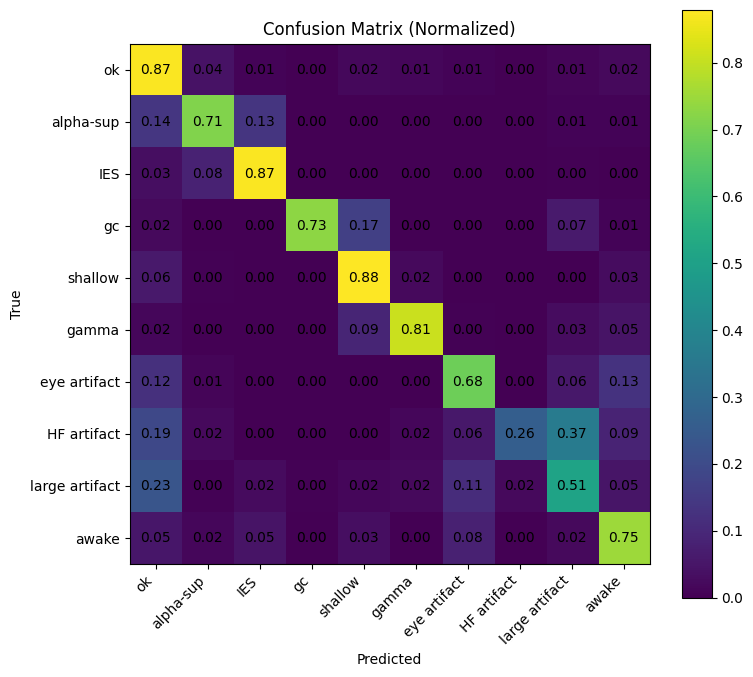

In [18]:
# ----------------------------
# Confusion matrix (time-bin level) on TEST
# ----------------------------

labels = list(range(NUM_CLASSES))
cm = confusion_matrix(y_test.astype(int), yhat_test.astype(int), labels=labels)

def plot_confusion_matrix(cm, class_names, normalize=True):
    cm_plot = cm.astype(np.float64)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, where=row_sums != 0)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    # Annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = cm_plot[i, j]
            text = f"{value:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, text, ha="center", va="center")

    plt.tight_layout()
    plt.show()
    
classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']
if ~MERGE_ENABLED:
    plot_confusion_matrix(cm, classes, normalize = True)
else:
    plot_confusion_matrix(cm, classes_merged, normalize = True)

In [19]:
xgb_clf.save_model(model_name + '.json')

In [ ]:
# load
new_model = xgb.XGBClassifier()
new_model.load_model(model_name + ".json")

# check optimal number of trees of loaded model
new_model.best_iteration

1095

# Features Importance

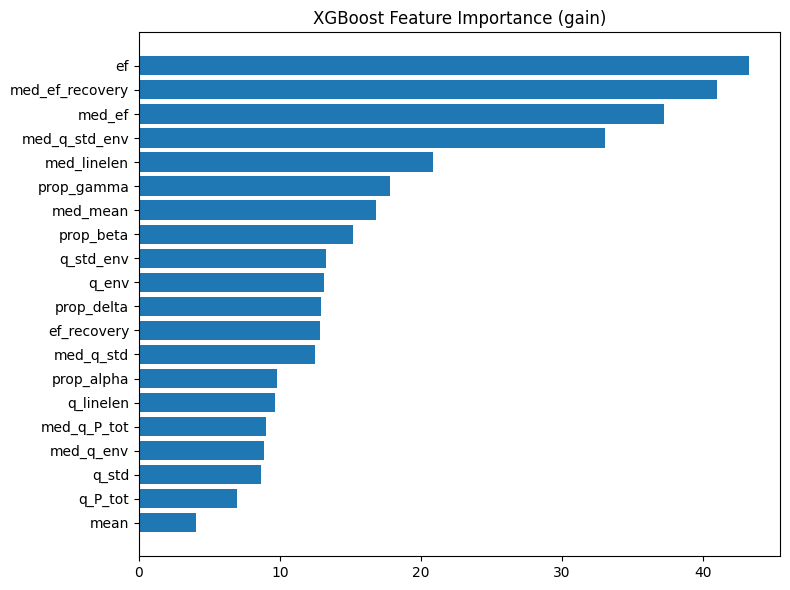

In [ ]:
def plot_xgb_importance(model, feature_names, importance_type="gain", top_k=None):
    """
    importance_type: 'weight', 'gain', or 'cover'
    """
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    # XGBoost names features as f0, f1, ...
    importance = []
    for i, name in enumerate(feature_names):
        importance.append(score.get(f"f{i}", 0.0))

    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False)

    if top_k is not None:
        df_imp = df_imp.head(top_k)

    plt.figure(figsize=(8, max(4, len(df_imp) * 0.3)))
    plt.barh(df_imp["feature"], df_imp["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"XGBoost Feature Importance ({importance_type})")
    plt.tight_layout()
    plt.show()

    return df_imp

df_importance = plot_xgb_importance(
    xgb_clf,
    features,
    importance_type="gain",   # <-- use gain
    top_k=20
)

In [ ]:
from sklearn.inspection import permutation_importance


COMPUTE_PERMUTATION_IMPORTANCE = False

def plot_permutation_importance(model, X_val, y_val, feature_names):
    result = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    df_perm = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, max(4, len(df_perm) * 0.3)))
    plt.barh(df_perm["feature"], df_perm["importance"])
    plt.gca().invert_yaxis()
    plt.title("Permutation Importance")
    plt.tight_layout()
    plt.show()

    return df_perm

if  COMPUTE_PERMUTATION_IMPORTANCE:
    df_perm = plot_permutation_importance(
        xgb_clf,
        X_val,
        y_val,
        feature_names
    )

# Visualize predicted mask

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


classes = ["ok", "alpha-sup", "IES", "gc", "shallow",
           "gamma", "eye artifact", "HF artifact",
           "large artifact", "awake"]

def annotate_mask(mask, class_names, title="Mask"):
    T = len(mask)

    plt.figure(figsize=(14, 2))
    plt.imshow(mask[None, :], aspect="auto")
    plt.yticks([])
    plt.title(title)

    # Find segment boundaries
    changes = np.where(mask[1:] != mask[:-1])[0] + 1
    segments = np.split(np.arange(T), changes)

    for seg in segments:
        start = seg[0]
        end = seg[-1]
        mid = (start + end) // 2
        label = class_names[mask[start]]
        plt.text(mid, 0, label,
                 ha="center", va="center",
                 fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()


def plot_spec_with_mask(x_log, mask, class_names, title):
    T = mask.shape[0]

    plt.figure(figsize=(14, 4))
    plt.imshow(x_log, aspect="auto", origin="lower")

    # Color bar for mask (transparent overlay)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(class_names))]

    for t in range(T):
        plt.axvspan(t, t+1, color=colors[mask[t]], alpha=0.08)

    # Legend
    patches = [mpatches.Patch(color=colors[i], label=class_names[i])
               for i in range(len(class_names))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Freq bin")
    plt.tight_layout()
    plt.show()

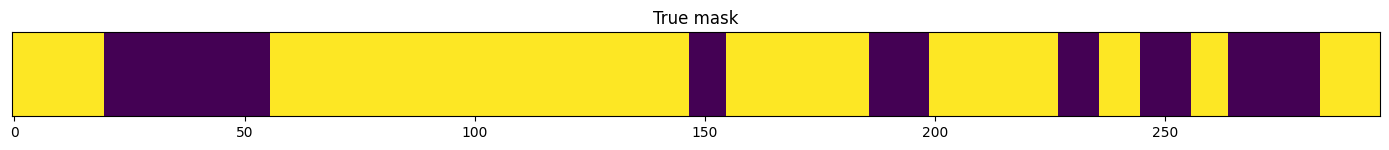

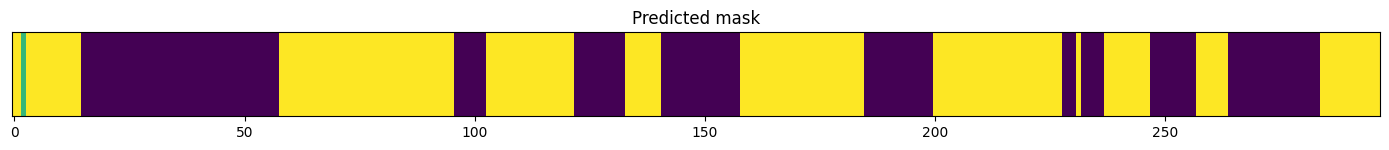

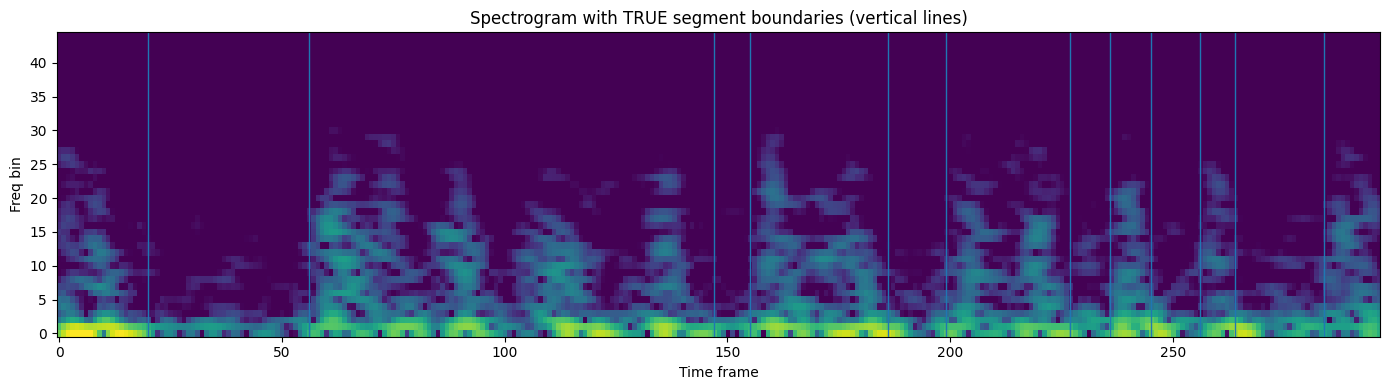

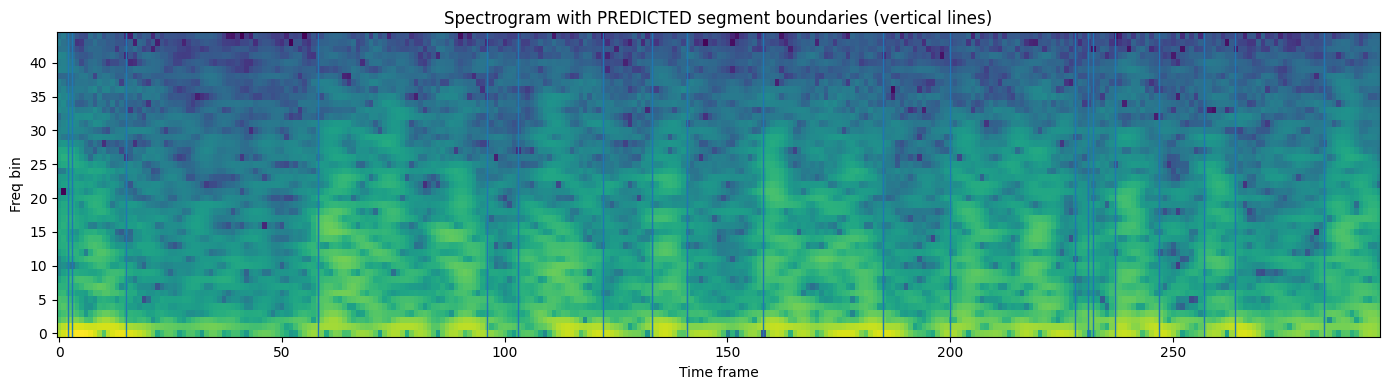

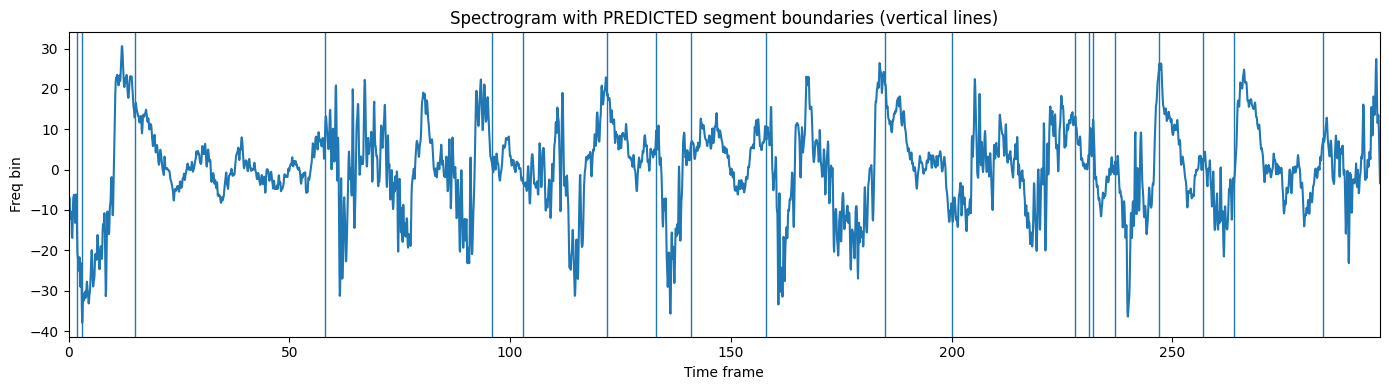

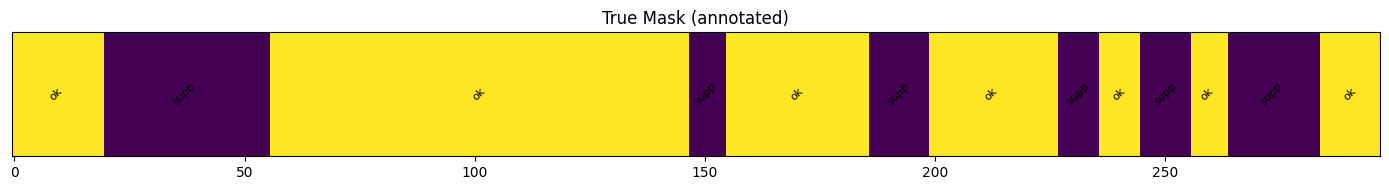

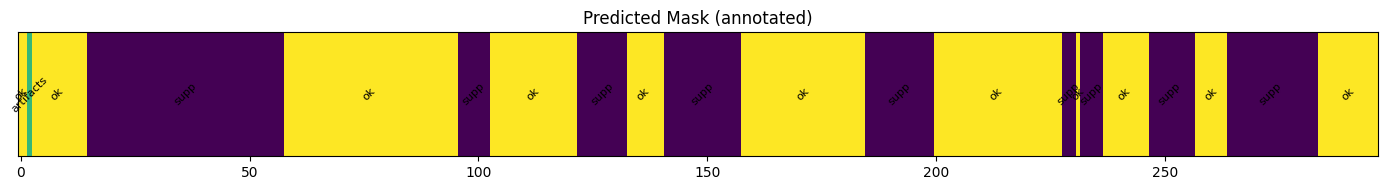

In [ ]:
idx = 10

test_groups = pd.unique(gid_test)

# spectrogram
eeg = X_eeg[test_groups[idx]]
x_norm = np.log2(X_spec[test_groups[idx]] + 0.000001)


def get_pred_on_test_data(group_to_plot: int, p_all: np.ndarray, y_all: np.ndarray, yhat_all: np.ndarray,
                              gid_all: np.ndarray, title: str):
    m = gid_all == group_to_plot
    if not np.any(m):
        print("Group not found in this split:", group_to_plot)
        return

    p = p_all[m]                 # (T, C)
    y_true = y_all[m].astype(int)     # (T,)
    y_pred = yhat_all[m].astype(int)

    return y_true, y_pred, m


# prediction
y_true, y_pred, m = get_pred_on_test_data(int(test_groups[idx]), p_test, y_test, yhat_test, gid_test, title="TEST (multiclass)")

# ---------- Masks as stripes ----------
plt.figure(figsize=(14, 1.6))
plt.imshow(y_true[None, :], aspect="auto")
plt.yticks([])
plt.title("True mask")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 1.6))
plt.imshow(y_pred[None, :], aspect="auto")
plt.yticks([])
plt.title("Predicted mask")
plt.tight_layout()
plt.show()

# ---------- Overlay mask boundaries on spectrogram ----------
def segment_boundaries(mask_1d: np.ndarray):
    # indices where label changes
    return np.where(mask_1d[1:] != mask_1d[:-1])[0] + 1

true_bounds = segment_boundaries(y_true)
pred_bounds = segment_boundaries(y_pred)

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower", vmin = -4, vmax = 8)
for t in true_bounds:
    plt.axvline(t, linewidth=1)  # true boundaries
plt.title("Spectrogram with TRUE segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(x_norm, aspect="auto", origin="lower")
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(np.linspace(0,297,1280*3),eeg)
plt.xlim(0,297)
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

if ~MERGE_ENABLED:
    annotate_mask(y_true, classes_merged, title="True Mask (annotated)")
    annotate_mask(y_pred, classes_merged, title="Predicted Mask (annotated)")
else:
    annotate_mask(y_true, classes, title="True Mask (annotated)")
    annotate_mask(y_pred, classes, title="Predicted Mask (annotated)")    

## Optional: Train LightGBM instead (swap-in)

If you prefer LGBM, set `USE_LGBM=True` below. (Keep everything else identical.)

In [ ]:

# ----------------------------
# Optional: train LightGBM (MULTICLASS)
# ----------------------------
USE_LGBM = True

if USE_LGBM:
    # LightGBM can take class_weight directly; we reuse the same balanced weights as above.
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multiclass",
        num_class=NUM_CLASSES,
        random_state=42,
        n_jobs=-1,
        class_weight=class_weight,
    )
    lgb_clf.fit(
        X_train, y_train.astype(int),
        eval_set=[(X_val, y_val.astype(int))],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
    )

    p_val = lgb_clf.predict_proba(X_val)
    p_test = lgb_clf.predict_proba(X_test)
    yhat_val = np.argmax(p_val, axis=1).astype(int)
    yhat_test = np.argmax(p_test, axis=1).astype(int)

    df_val = dice_multiclass_per_group(y_val, yhat_val, gid_val, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)
    df_test = dice_multiclass_per_group(y_test, yhat_test, gid_test, num_classes=NUM_CLASSES, ignore_classes=IGNORE_CLASSES_FOR_DICE)

    print("Val macro Dice (mean over recordings):", float(df_val["macro_dice"].mean()), " median:", float(df_val["macro_dice"].median()))
    print("Test macro Dice (mean over recordings):", float(df_test["macro_dice"].mean()), " median:", float(df_test["macro_dice"].median()))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12788
[LightGBM] [Info] Number of data points in the train set: 105435, number of used features: 60
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


C:\Users\holcman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\holcman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Val macro Dice (mean over recordings): 0.6989721981698854  median: 0.6775436929088126
Test macro Dice (mean over recordings): 0.7400493672977561  median: 0.7581699346405228


## Visual check: reconstruction of predictions for one recording

We reconstruct the per-time predictions for a chosen `group_id` and plot probabilities + predicted mask vs true mask.

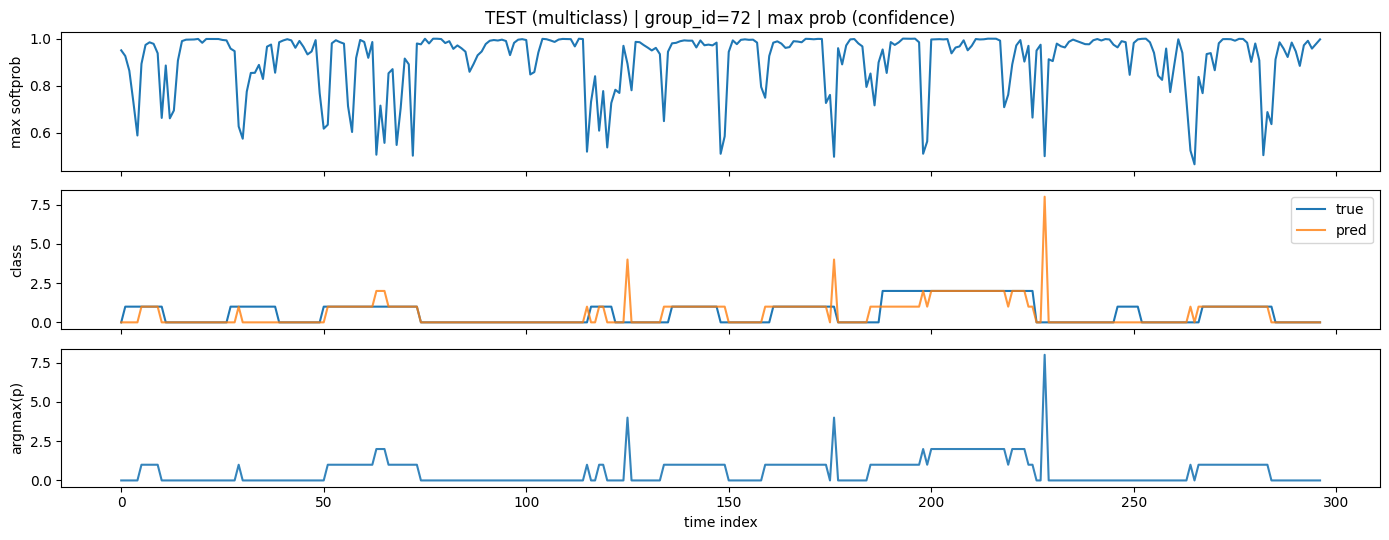

In [ ]:

# ----------------------------
# Optional: plot per-time "confidence" (max class prob) + class labels over time for one test group
# ----------------------------
def plot_recording_multiclass(group_to_plot: int, p_all: np.ndarray, y_all: np.ndarray, yhat_all: np.ndarray,
                              gid_all: np.ndarray, title: str):
    m = gid_all == group_to_plot
    if not np.any(m):
        print("Group not found in this split:", group_to_plot)
        return

    p = p_all[m]                 # (T, C)
    y = y_all[m].astype(int)     # (T,)
    yhat = yhat_all[m].astype(int)

    conf = np.max(p, axis=1)     # (T,)
    pred_class = np.argmax(p, axis=1)

    fig, ax = plt.subplots(3, 1, figsize=(14, 5.5), sharex=True)
    ax[0].plot(conf)
    ax[0].set_title(f"{title} | group_id={group_to_plot} | max prob (confidence)")
    ax[0].set_ylabel("max softprob")

    ax[1].plot(y, label="true")
    ax[1].plot(yhat, label="pred", alpha=0.8)
    ax[1].set_ylabel("class")
    ax[1].legend()

    ax[2].plot(pred_class, alpha=0.9)
    ax[2].set_ylabel("argmax(p)")
    ax[2].set_xlabel("time index")

    plt.tight_layout()
    plt.show()

test_groups = pd.unique(gid_test)
if len(test_groups) > 0:
    g0 = int(test_groups[idx])
    plot_recording_multiclass(g0, p_test, y_test, yhat_test, gid_test, title="TEST (multiclass)")
